# Dissertation implementation

In [ ]:
#@title setup and install dependencies

%%capture
!pip install -q transformers datasets torch scikit-learn pandas numpy


import os
import json
from typing import Dict, List, Any, Tuple
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EvalPrediction,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("  All dependencies installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

In [ ]:
#@title config

import os
import torch

# google drive paths
# NOTE FOR ANYONE USING THIS - CHANGE DRIVE PATHS TO WHATEVER YOURS IS, I HAVENT HAD TIME TO TEST IT WITH ON DEVICE FILES DUE TO DEADLINE
CURRENT_STAGE =  2
DRIVE_PATH = "/content/drive/My Drive/Uni"  # Google Drive root
MODELS_FOLDER = os.path.join(DRIVE_PATH, "models")
DATASETS_FOLDER = os.path.join(DRIVE_PATH, "datasets")
INPUT_FILE = os.path.join(DATASETS_FOLDER, "Phishfuzzer_emails_orignal_seed_v1.json")  # Upload your file
OUTPUT_DIR = os.path.join(MODELS_FOLDER, "MattPhishingBERT_stage_0")

# model settings
MODEL_ID = "FacebookAI/roberta-base"
MODE = "strict"  # "strict" or "relaxed"
USE_SUBJECT = True
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3
MAX_LENGTH = 512
TEST_SIZE = 0.2
VAL_SIZE = 0.1
RANDOM_SEED = 42

#labels
STRICT_LABELS = ["Phishing", "Spam", "Valid"]
RELAXED_LABELS = ["Unwanted", "Valid"]

LABELS = STRICT_LABELS if MODE == "strict" else RELAXED_LABELS
NUM_LABELS = len(LABELS)

LABEL2ID = {lbl: i for i, lbl in enumerate(LABELS)}
ID2LABEL = {i: lbl for i, lbl in enumerate(LABELS)}

# column names - MUST MATCH JSON KEYS!!!!
LABEL_COLUMN = "Type"
TEXT_BODY_COLUMN = "Body"
TEXT_SUBJECT_COLUMN = "Subject"
SOURCE_COLUMN = "Source"

# device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Configuration loaded")
print(f"   Mode: {MODE}")
print(f"   Device: {DEVICE}")
print(f"   Labels: {LABELS}")
print(f"   Input: {INPUT_FILE}")
print(f"   Output: {OUTPUT_DIR}")
print(f"\nColumns:")
print(f"   Label: {LABEL_COLUMN}")
print(f"   Body: {TEXT_BODY_COLUMN}")
print(f"   Subject: {TEXT_SUBJECT_COLUMN}")
print(f"   Source: {SOURCE_COLUMN}")

Configuration loaded
   Mode: strict
   Device: cuda
   Labels: ['Phishing', 'Spam', 'Valid']
   Input: /content/drive/My Drive/Uni/datasets/meajor_cleaned_preprocessed.json
   Output: /content/drive/My Drive/Uni/models/MattPhishingBERT_stage_0

Columns:
   Label: Type
   Body: Body
   Subject: Subject
   Source: Source


In [ ]:
#@title utility functions

import os
import json
from typing import List
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix

def normalize_category(lbl) -> str:
    """
    Normalize dataset labels to: Phishing, Spam, Valid, Unknown.

    Supports:
    - Dataset strings like "Phishing", "Spam", "Benign"
    - Common ham/benign synonyms
    - Numeric encodings if you ever have them
    """
    if lbl is None:
        return "Unknown"

    s = str(lbl).strip().lower()
    if not s:
        return "Unknown"

    # Common mappings
    if s in ("phishing", "phish"):
        return "Phishing"
    if s in ("spam", "junk"):
        return "Spam"
    if s in ("valid", "benign", "ham", "legitimate", "legit", "non-spam", "nonspam"):
        return "Valid"

    # Numeric mappings
    if s == "0":
        return "Valid"
    if s == "1":
        return "Phishing"
    if s == "2":
        return "Phishing"

    return "Unknown"

def to_relaxed(lbl: str) -> str:
    """Convert strict labels to 2-class labels."""
    return "Unwanted" if lbl in ("Phishing", "Spam") else "Valid"

def detect_group(rec: dict) -> str:
    """Identify group based on source."""
    src = (rec.get(SOURCE_COLUMN) or "").strip().lower()

    group_mapping = {
        "trec5": "TREC-05",
        "trec6": "TREC-06",
        "trec7": "TREC-07",
        "trec-5": "TREC-05",
        "trec-6": "TREC-06",
        "trec-7": "TREC-07",
        "enron": "Enron",
        "nazario": "Nazario",
        "nigerian": "Nigerian",
        "ceas": "CEAS",
        "spamassassin": "SpamAssassin",
        "spam": "SpamAssassin",
        "ling": "Ling",
        "synthetic": "Synthetic",
    }

    for key, group_name in group_mapping.items():
        if key in src:
            return group_name

    return src if src else "Unknown"

def get_text(rec: dict) -> str:
    """Extract email text (Subject + Body if USE_SUBJECT=True)."""
    body = rec.get(TEXT_BODY_COLUMN, "") or ""
    subj = rec.get(TEXT_SUBJECT_COLUMN, "") or ""

    if USE_SUBJECT:
        return (str(subj).strip() + "\n\n" + str(body).strip()).strip()

    return str(body).strip()

def load_dataset(path: str):
    """Load JSON dataset."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_model(model_dir: str, device: str):
    """Load fine-tuned model."""
    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Model not found: {model_dir}")

    print(f"Loading model from {model_dir}")
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(device)
    model.eval()
    return tokenizer, model

def predict_batch(
    texts: List[str],
    model,
    tokenizer,
    device: str,
    batch_size: int = 32,
    max_length: int = 512
) -> List[str]:
    """Run batch inference."""
    predictions = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]

            encodings = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            ).to(device)

            logits = model(**encodings).logits
            pred_ids = torch.argmax(logits, dim=-1).tolist()
            predictions.extend([model.config.id2label[pid] for pid in pred_ids])

    return predictions

def evaluate_group(rows: list, mode: str) -> dict:
    """Evaluate group performance."""
    true_labels = [r["true_label"] for r in rows]
    pred_labels = [r["pred_label"] for r in rows]

    # This function is written for strict eval in the notebook.
    labels = STRICT_LABELS

    strict_report = classification_report(
        true_labels, pred_labels, labels=labels,
        zero_division=0, output_dict=True
    )
    strict_cm = confusion_matrix(true_labels, pred_labels, labels=labels)
    strict_acc = strict_cm.trace() / strict_cm.sum() if strict_cm.sum() else 0.0

    return {
        "strict_report": strict_report,
        "strict_cm": strict_cm,
        "strict_accuracy": strict_acc,
        "n": len(rows),
    }

print("  Utility functions loaded")

  Utility functions loaded


In [ ]:
#@title dataset class

class EmailDataset(Dataset):
    """PyTorch Dataset for email classification"""
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

print("Dataset class loaded")

Dataset class loaded


In [ ]:
#@title diagnostic check

print("=" * 80)
print("DIAGNOSTIC: Checking Dataset")
print("=" * 80)

try:
    data = load_dataset("/content/drive/MyDrive/Uni/datasets/meajor_cleaned_preprocessed.json")
    print(f"\n   Loaded {len(data)} records\n")

    # Check first record
    rec = data[0]
    print("   First record structure:")
    for key in rec.keys():
        val = rec[key]
        if isinstance(val, str):
            preview = val[:40] + "..." if len(val) > 40 else val
        else:
            preview = str(val)[:40]
        print(f"   {key:20s}: {preview}")

    # Test processing on first 5
    print(f"\n   Testing processing on first 5 records:\n")
    for i, rec in enumerate(data[:5]):
        label_raw = rec.get(LABEL_COLUMN, "N/A")
        label_norm = normalize_category(label_raw)
        text = get_text(rec)[:60] + "..."
        group = detect_group(rec)

        status = "Good" if label_norm != "Unknown" else "Error"
        print(f"{status} Record {i}: {label_norm:10s} | {group:15s} | {text}")

    # Count labels
    print(f"\n   Label distribution:")
    labels_list = [normalize_category(rec.get(LABEL_COLUMN, "")) for rec in data]
    from collections import Counter
    counts = Counter(labels_list)
    for label in STRICT_LABELS:
        count = counts.get(label, 0)
        pct = (count / len(data)) * 100 if count > 0 else 0
        print(f"   {label:15s}: {count:7d} ({pct:5.1f}%)")

    unknown = counts.get("Unknown", 0)
    print(f"   {'Unknown':15s}: {unknown:7d} ({unknown/len(data)*100:5.1f}%)")

    if unknown > 0:
        print(f"\n   WARNING: {unknown} unknown labels found")

except Exception as e:
    print(f"   Error: {e}")
    print("\nMake sure:")
    print("  1. Dataset file is uploaded")
    print("  2. Column names are correct")
    print("  3. File is valid JSON")

print("\n" + "=" * 80)

DIAGNOSTIC: Checking Dataset

   Loaded 108685 records

   First record structure:
   sender              : d66e9e64b006d6bca649f1c945129c42c4383687...
   sender_domain       : enron.com
   receiver            : 35c5a9fb9fba3b8737ed7cef2a87e427a73db4fc...
   receiver_domain     : enron.com
   date                : 2001-06-29 09:37:04-05:00
   subject             : [ORGANIZATION] failover plan.
   content_types       : text/plain
   body                : Hi [NAME],  

Tonight we are rolling out...
   urls                : 
   url_count           : 0.0
   url_length_max      : 0.0
   url_length_avg      : 0.0
   url_subdom_max      : 0.0
   url_subdom_avg      : 0.0
   attachment_count    : 0.0
   has_attachments     : False
   attachment_types    : 
   language            : en
   source              : trec5
   label               : benign

   Testing processing on first 5 records:

Error Record 0: Unknown    | Unknown         | ...
Error Record 1: Unknown    | Unknown         | ...
Erro

In [ ]:
#@title Training

%%time

print("=" * 80)
print("TRAINING")
print("=" * 80)

# Load data
print(f"\nLoading dataset from {INPUT_FILE}")
data = load_dataset(INPUT_FILE)

texts = []
labels_str = []
groups = []

skipped_unknown = 0
skipped_empty = 0

for rec in data:
    typ = normalize_category(rec.get(LABEL_COLUMN, ""))
    if typ == "Unknown":
        skipped_unknown += 1
        continue

    if MODE == "relaxed":
        typ = to_relaxed(typ)

    text = get_text(rec)
    if not text:
        skipped_empty += 1
        continue

    gname = detect_group(rec)

    texts.append(text)
    labels_str.append(typ)
    groups.append(gname)

labels = [LABEL2ID[lbl] for lbl in labels_str]

print(f"\n   Summary:")
print(f"  Total records: {len(data)}")
print(f"  Skipped (Unknown): {skipped_unknown}")
print(f"  Skipped (Empty): {skipped_empty}")
print(f"  Used: {len(texts)}")
print(f"\nLabel distribution: {pd.Series(labels_str).value_counts().to_dict()}")

# Split data
texts_train, texts_test, labels_train, labels_test, groups_train, groups_test = train_test_split(
    texts, labels, groups, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=labels
)

texts_train, texts_val, labels_train, labels_val, groups_train, groups_val = train_test_split(
    texts_train, labels_train, groups_train, test_size=VAL_SIZE,
    random_state=RANDOM_SEED, stratify=labels_train
)

print(f"\n   Splits: Train={len(texts_train)}, Val={len(texts_val)}, Test={len(texts_test)}")

# Load model
print(f"\nLoading model: {MODEL_ID}")

# If loading from checkpoint, use roberta tokenizer
if "checkpoint" in MODEL_ID or CURRENT_STAGE > 1:
    print("Loading RoBERTa tokenizer (base model)...")
    tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")
else:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

# Create datasets
train_dataset = EmailDataset(texts_train, labels_train, tokenizer, MAX_LENGTH)
val_dataset = EmailDataset(texts_val, labels_val, tokenizer, MAX_LENGTH)
test_dataset = EmailDataset(texts_test, labels_test, tokenizer, MAX_LENGTH)

# Training args
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    logging_steps=50,
    seed=RANDOM_SEED,
    report_to="none",
)

# Metrics
def compute_metrics(pred: EvalPrediction):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    rep = classification_report(
        labels, preds, labels=list(range(NUM_LABELS)),
        output_dict=True, zero_division=0
    )

    acc = sum(labels == preds) / len(labels) if len(labels) > 0 else 0

    metrics = {"accuracy": acc}
    for i, lbl in enumerate(LABELS):
        metrics[f"f1_{lbl}"] = rep[str(i)]["f1-score"]

    return metrics

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# Train
print("\n" + "=" * 80)
print("Starting training...")
trainer.train()

# Test evaluation
print("\n" + "=" * 80)
print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(labels_test, preds, labels=list(range(NUM_LABELS)))
df_cm = pd.DataFrame(
    cm,
    index=[f"True {LABELS[i]}" for i in range(NUM_LABELS)],
    columns=[f"Pred {LABELS[i]}" for i in range(NUM_LABELS)],
)

print("\n  Test Confusion Matrix:")
print(df_cm)

rep = classification_report(labels_test, preds, target_names=LABELS, zero_division=0)
print("\n  Test Classification Report:")
print(rep)

# Save model
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n   Model saved to {OUTPUT_DIR}")

TRAINING

Loading dataset from /content/drive/My Drive/Uni/datasets/meajor_cleaned_preprocessed.json

   Summary:
  Total records: 108685
  Skipped (Unknown): 1
  Skipped (Empty): 0
  Used: 108684

Label distribution: {'Valid': 60650, 'Phishing': 48034}

   Splits: Train=78252, Val=8695, Test=21737

Loading model: FacebookAI/roberta-base
Loading RoBERTa tokenizer (base model)...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating on test set...



  Test Confusion Matrix:
               Pred Phishing  Pred Spam  Pred Valid
True Phishing           9493          0         114
True Spam                  0          0           0
True Valid                51          0       12079


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

In [ ]:
#@title testing
%%time

print("=" * 80)
print("TESTING AND STATISTICS")
print("=" * 80)

print(f"\n   Model Source: {MODEL_SOURCE.upper()}")

if MODEL_SOURCE == "base":
    print(f"Loading base model: {MODEL_ID}")
    tokenizer_eval = AutoTokenizer.from_pretrained(MODEL_ID)
    model_eval = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID, num_labels=NUM_LABELS, ignore_mismatched_sizes=True,
    )
    model_eval.config.id2label = ID2LABEL
    model_eval.config.label2id = LABEL2ID

elif MODEL_SOURCE == "fine_tuned":
    print(f"Loading fine-tuned model from {OUTPUT_DIR}")
    tokenizer_eval, model_eval = load_model(OUTPUT_DIR, DEVICE)

model_eval.to(DEVICE)
model_eval.eval()
print(f"   Model loaded | Device: {DEVICE}")

# load and prepare data
print(f"\n   Loading dataset from {INPUT_FILE}")
data = load_dataset(INPUT_FILE)

groups = {}
texts_to_score = []
row_refs = []

print("  Preparing data...")
skipped_unknown = 0
skipped_empty = 0

for i, rec in enumerate(data):
    typ = normalize_category(rec.get(LABEL_COLUMN, ""))
    if typ == "Unknown":
        skipped_unknown += 1
        continue

    if MODE == "relaxed":
        typ = to_relaxed(typ)

    text = get_text(rec)
    if not text:
        skipped_empty += 1
        continue

    gname = detect_group(rec)

    if gname not in groups:
        groups[gname] = []

    row = {
        "No.": str(rec.get("No.", i)),
        "group": gname,
        "true_label": typ,
        "pred_label": "",
    }
    groups[gname].append(row)
    texts_to_score.append(text)
    row_refs.append(row)

print(f"   Loaded: {len(data)} | Used: {len(row_refs)} | Skipped: {skipped_unknown + skipped_empty}")

print(f"\n   Label distribution:")
label_counts = {}
for row in row_refs:
    lbl = row["true_label"]
    label_counts[lbl] = label_counts.get(lbl, 0) + 1
for lbl in LABELS:
    count = label_counts.get(lbl, 0)
    pct = (count / len(row_refs) * 100) if row_refs else 0
    print(f"  {lbl:15s}: {count:7d} ({pct:5.1f}%)")

print(f"\n   Emails per group:")
for g, rows in sorted(groups.items()):
    print(f"  {g:20s}: {len(rows):5d}")

# run predictions
print(f"\n   Running predictions...")
predictions = predict_batch(
    texts_to_score, model_eval, tokenizer_eval, DEVICE,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH,
)

assert len(predictions) == len(row_refs), "Mismatch!"

for row, pred in zip(row_refs, predictions):
    row["pred_label"] = pred

# evaluate
print("\n" + "=" * 80)
print("GROUP-WISE RESULTS")
print("=" * 80)

results = {}
for gname, rows in sorted(groups.items()):
    print(f"\n   {gname}:")
    res = evaluate_group(rows, MODE)
    results[gname] = res

    print(f"   Emails: {res['n']}")
    print(f"     Accuracy: {res['strict_accuracy']:.2%}")

    strict_df = pd.DataFrame(
        res["strict_cm"],
        index=[f"True {l}" for l in LABELS],
        columns=[f"Pred {l}" for l in LABELS],
    )
    print("\n" + strict_df.to_string().replace("\n", "\n   "))

    print("\n   Per-class metrics:")
    rep = res["strict_report"]
    for lbl in LABELS:
        f1 = rep.get(lbl, {}).get("f1-score", 0.0)
        prec = rep.get(lbl, {}).get("precision", 0.0)
        rec_sc = rep.get(lbl, {}).get("recall", 0.0)
        print(f"      {lbl:10s}: F1={f1:.3f} | Prec={prec:.3f} | Rec={rec_sc:.3f}")

# summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80 + "\n")

summary_rows = []
for gname, res in sorted(results.items()):
    rep = res["strict_report"]
    summary_rows.append({
        "Group": gname,
        "N": res['n'],
        "Accuracy": f"{res['strict_accuracy']:.2%}",
        "F1_Phishing": f"{rep.get('Phishing', {}).get('f1-score', 0.0):.3f}",
        "F1_Spam": f"{rep.get('Spam', {}).get('f1-score', 0.0):.3f}",
        "F1_Valid": f"{rep.get('Valid', {}).get('f1-score', 0.0):.3f}",
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
else:
    print("No results to display")

# overall stats
print("\n" + "=" * 80)
print("OVERALL STATISTICS")
print("=" * 80)

if MODEL_SOURCE == "base":
    print("\n  BASELINE MODEL (No Fine-Tuning)")
    print("   This is a pretrained model for comparison.")

if results:
    total_correct = sum(r['strict_cm'].trace() for r in results.values())
    total_samples = sum(r['n'] for r in results.values())
    overall_acc = total_correct / total_samples if total_samples > 0 else 0

    print(f"\n   Overall Accuracy: {overall_acc:.2%}")
    print(f"   Correct: {int(total_correct)} / {total_samples}")
else:
    print("\n  No results to display")

print("\n" + "=" * 80)

TESTING AND STATISTICS


NameError: name 'MODEL_SOURCE' is not defined

# graph explainer code using captum and matplotlib

In [ ]:
#@title explainer setup
# importing all required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost
import joblib



In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.2 MB/s eta 0:00:00


In [ ]:
# @title reload test data (if training cell already ran)

print("Reloading test data from training...")

# Re-load and re-split the dataset (same as training cell)
data = load_dataset("/content/drive/My Drive/Uni/datasets/PhishFuzzer_emails_original_seed_v1.json")

texts = []
labels_str = []

for rec in data:
    typ = normalize_category(rec.get(LABEL_COLUMN, ""))
    if typ == "Unknown":
        continue

    if MODE == "relaxed":
        typ = to_relaxed(typ)

    text = get_text(rec)
    if not text:
        continue

    texts.append(text)
    labels_str.append(typ)

labels = [LABEL2ID[lbl] for lbl in labels_str]

# Same split as training
texts_train, texts_test, labels_train, labels_test, _, _ = train_test_split(
    texts, labels, range(len(texts)), test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=labels
)

texts_train, texts_val, labels_train, labels_val, _, _ = train_test_split(
    texts_train, labels_train, range(len(texts_train)), test_size=VAL_SIZE,
    random_state=RANDOM_SEED, stratify=labels_train
)

print(f"   Test data reloaded")
print(f"   texts_test: {len(texts_test)} samples")
print(f"   labels_test: {len(labels_test)} samples")

Reloading test data from training...
   Test data reloaded
   texts_test: 660 samples
   labels_test: 660 samples


TOKEN-LEVEL INTERPRETABILITY - SAME SAMPLES FOR BASE & FINE-TUNED
Fine-tuned Model: /content/drive/My Drive/Uni/models/MattPhishingBERT_meajor_cleaned_preprocessed/checkpoint-14673 (from Google Drive)

Selecting 2 samples from each class...
Phishing: 225 total, selected 2
Spam: 215 total, selected 2
Valid: 220 total, selected 2

Total samples selected: 6

✓ Samples saved to captum_samples.json


fine-tuned model

analysing: fine_tuned
Model: /content/drive/My Drive/Uni/models/MattPhishingBERT_meajor_cleaned_preprocessed/checkpoint-14673
Source: Google Drive

Loading tokenizer...
Tokenizer loaded

Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded on cuda

Setting up Integrated Gradients explainer...
Explainer ready

Computing token attributions for 6 samples...

sample 1/6
Ground Truth:  Phishing
Predicted:     Phishing (100.0%)
Status:        CORRECT
Text: REGISTER YOUR ACCOUNT ON THE NEW USAA PORTAL NOW

my message......

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


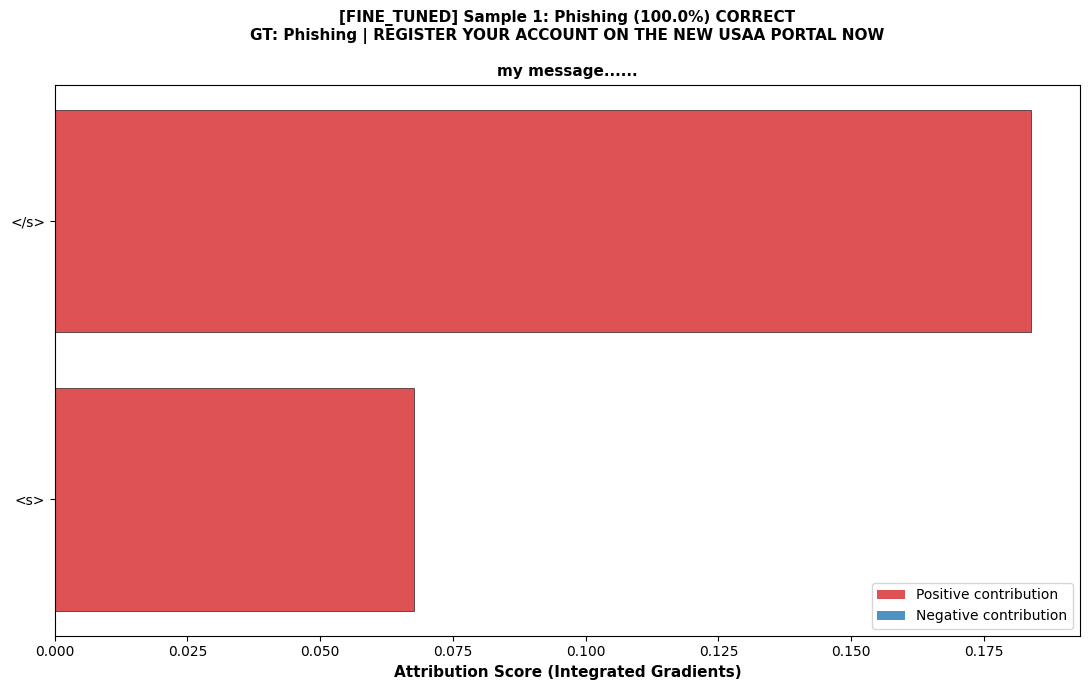


sample 2/6
Ground Truth:  Phishing
Predicted:     Phishing (100.0%)
Status:        CORRECT
Text: Confirm Your Shipping Details For Your Package

Shipping Details Needed For Your Package...

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


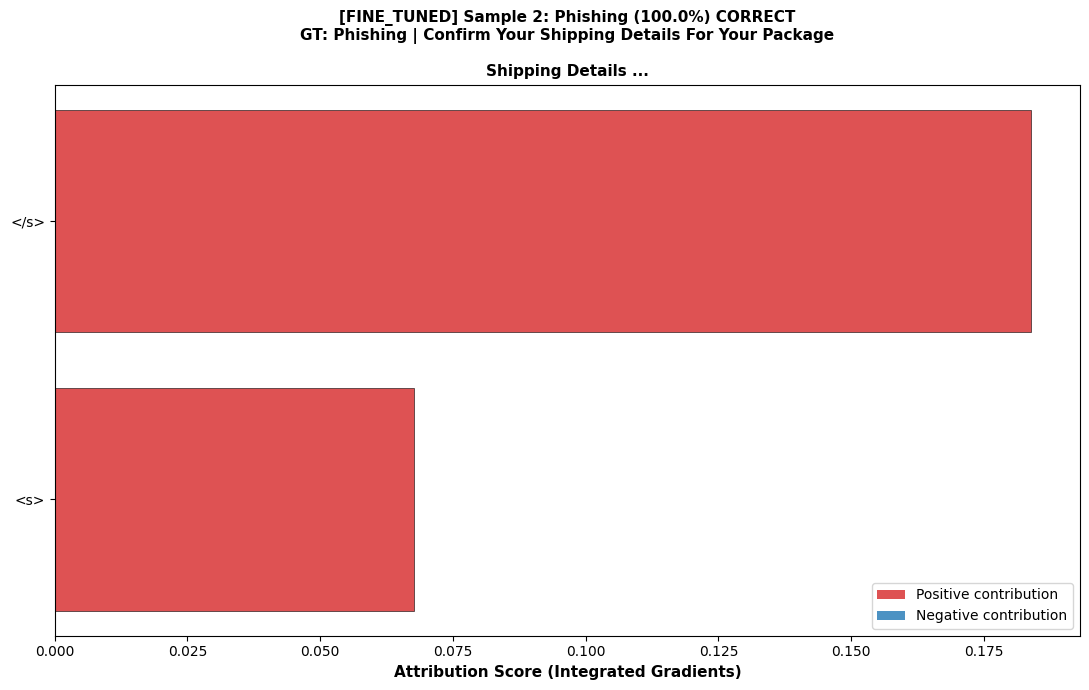


sample 3/6
Ground Truth:  Spam
Predicted:     Phishing (100.0%)
Status:        WRONG
Text: THE HUMAN ARCHIPELAGO

This blog, The Human Archipelago, deals with politics, history, geopolitics, ...

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


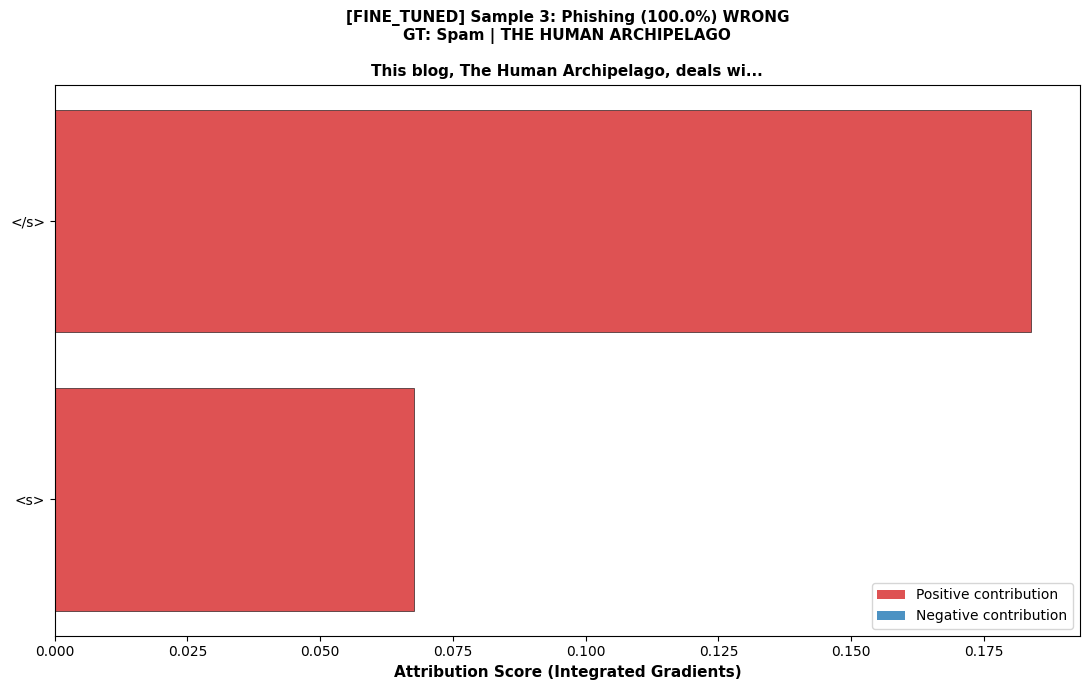


sample 4/6
Ground Truth:  Spam
Predicted:     Phishing (100.0%)
Status:        WRONG
Text: [REMINDER] Claim your free success tools

Use these tools to inspire & engage others – even at home ...

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


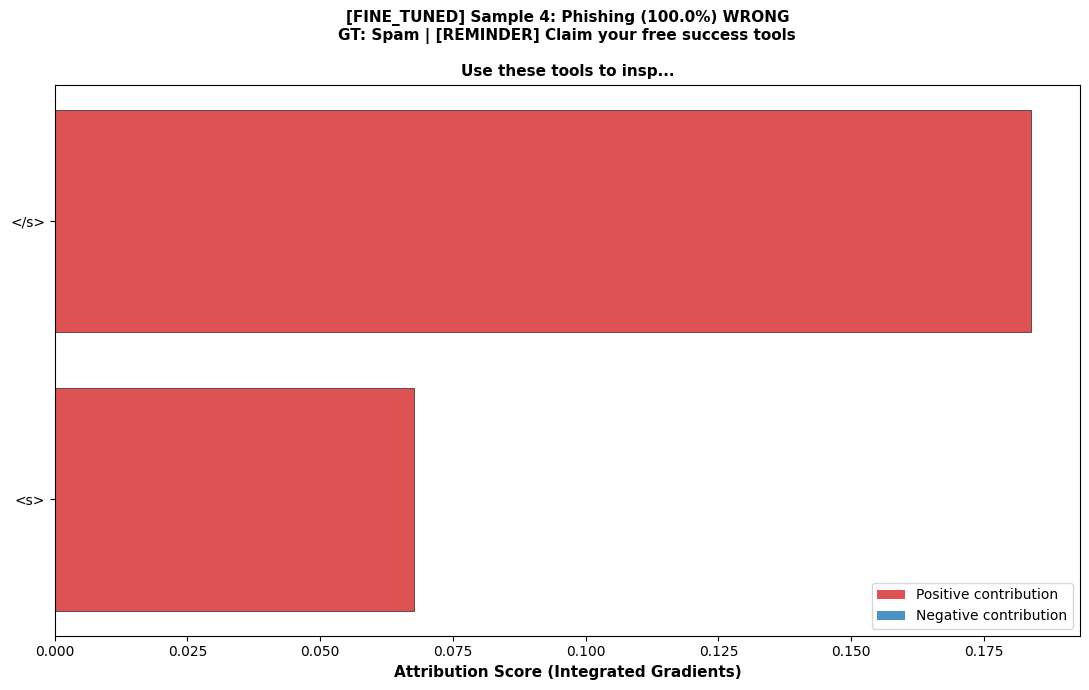


sample 5/6
Ground Truth:  Valid
Predicted:     Phishing (100.0%)
Status:        WRONG
Text: [Spambayes-checkins] SF.net SVN: spambayes: [3157] trunk/website

Revision: 3157 http://spambayes.sv...

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


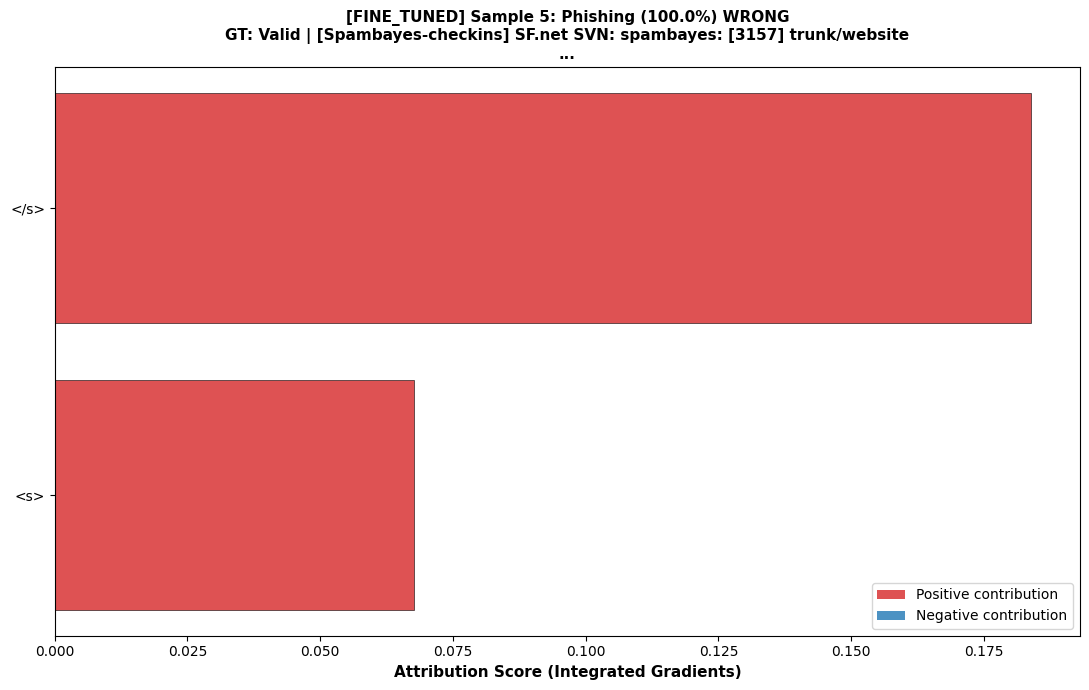


sample 6/6
Ground Truth:  Valid
Predicted:     Phishing (100.0%)
Status:        WRONG
Text: [IIU] Eircom aDSL Nat'ing

Hi all, apologies for the possible silly question (i don't think it is, b...

Computing Integrated Gradients...

Top 15 important tokens:
Rank   Token                Attribution 
------------------------------------------------------------
1      </s>                      0.1839
2      <s>                       0.0676


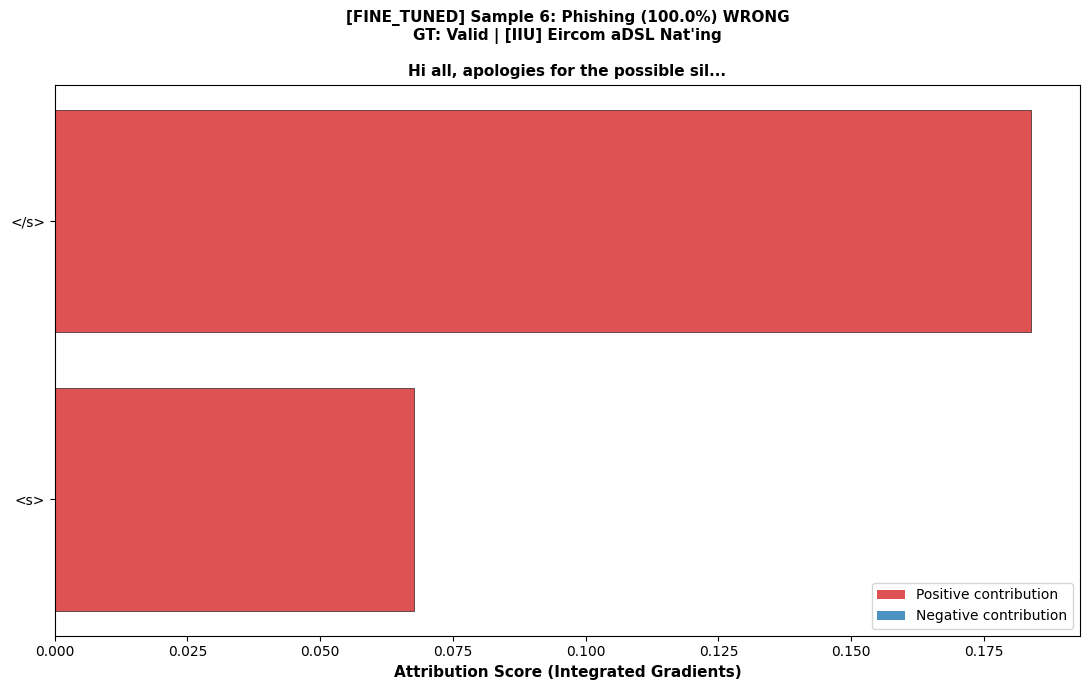


Completed analysis for fine_tuned

analysis complete

Generated 12 visualizations:
  • 6 visualizations for fine tuned model (Google Drive)

Both models analyzed on the same 6 samples
Sample config saved to: captum_samples.json

Files created:
  - captum_base_sample_1.png
  - captum_fine_tuned_sample_1.png
  - captum_base_sample_2.png
  - captum_fine_tuned_sample_2.png
  - captum_base_sample_3.png
  - captum_fine_tuned_sample_3.png
  - captum_base_sample_4.png
  - captum_fine_tuned_sample_4.png
  - captum_base_sample_5.png
  - captum_fine_tuned_sample_5.png
  - captum_base_sample_6.png
  - captum_fine_tuned_sample_6.png


In [ ]:
#@title captum explainer - SAME SAMPLES FOR BASE & FINE-TUNED

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import captum
from captum.attr import LayerIntegratedGradients
import warnings
import json
import os
warnings.filterwarnings('ignore')

print("=" * 80)
print("TOKEN-LEVEL INTERPRETABILITY - SAME SAMPLES FOR BASE & FINE-TUNED")
print("=" * 80)

# Define variables
DRIVE_PATH = "/content/drive/My Drive/Uni"
MODELS_FOLDER = os.path.join(DRIVE_PATH, "models")
FINETUNED_MODEL_PATH = os.path.join(MODELS_FOLDER, "MattPhishingBERT_meajor_cleaned_preprocessed/checkpoint-14673")
#BASE_MODEL_NAME = "roberta-base"

#print(f"\nBase Model: {BASE_MODEL_NAME} (from Hugging Face)")
print(f"Fine-tuned Model: {FINETUNED_MODEL_PATH} (from Google Drive)")

# Select and save samples
print(f"\nSelecting 2 samples from each class...")

sample_indices = []
sample_texts = []
sample_labels = []
sample_ground_truth = []

# Use same seed for reproducibility
np.random.seed(42)

for class_idx, class_name in enumerate(LABELS):
    class_samples = np.where(np.array(labels_test) == class_idx)[0]

    if len(class_samples) == 0:
        print(f"No samples found for class '{class_name}'")
        continue

    selected = np.random.choice(class_samples, min(2, len(class_samples)), replace=False)

    print(f"{class_name}: {len(class_samples)} total, selected {len(selected)}")

    for idx in selected:
        # Convert numpy types to Python types for JSON serialization
        sample_indices.append(int(idx))
        sample_texts.append(texts_test[int(idx)])
        sample_labels.append(LABELS[labels_test[int(idx)]])
        sample_ground_truth.append(int(labels_test[int(idx)]))

print(f"\nTotal samples selected: {len(sample_indices)}\n")

# Save samples
with open('captum_samples.json', 'w') as f:
    json.dump({
        'indices': sample_indices,
        'texts': sample_texts,
        'labels': sample_labels,
        'ground_truth': sample_ground_truth
    }, f, indent=2)

print("✓ Samples saved to captum_samples.json\n")


# Explainer function

def run_explainer_on_model(model_path, model_name, tokenizer_path, sample_texts, sample_ground_truth, sample_labels, is_huggingface=False):
    """
    Run explainer on a model with the given samples
    """
    print(f"\n{'=' * 80}")
    print(f"analysing: {model_name}")
    print(f"Model: {model_path}")
    print(f"Source: {'Hugging Face' if is_huggingface else 'Google Drive'}")
    print(f"{'=' * 80}\n")

    # Load tokenizer
    print(f"Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    print(f"Tokenizer loaded\n")

    # Load model
    print(f"Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.eval().to(DEVICE)
    print(f"Model loaded on {DEVICE}\n")

    # Setup explainer
    print("Setting up Integrated Gradients explainer...")

    def model_forward(input_ids):
        outputs = model(input_ids=input_ids)
        return outputs.logits

    embedding_layer = model.roberta.embeddings.word_embeddings
    lig = LayerIntegratedGradients(model_forward, embedding_layer)
    print("Explainer ready\n")

    print(f"Computing token attributions for {len(sample_texts)} samples...\n")

    # Process each sample
    for sample_num, (text, gt_label) in enumerate(zip(sample_texts, sample_ground_truth)):
        print(f"{'='*80}")
        print(f"sample {sample_num + 1}/{len(sample_texts)}")
        print(f"{'='*80}")

        gt_label_name = LABELS[gt_label]

        encoding = tokenizer(
            text,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        ).to(DEVICE)

        tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
        input_ids = encoding['input_ids']

        with torch.no_grad():
            outputs = model(**encoding)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)

        pred_class = torch.argmax(logits[0]).item()
        pred_label = LABELS[pred_class]
        confidence = probs[0][pred_class].item()

        is_correct = pred_class == gt_label
        correctness_icon = "CORRECT" if is_correct else "WRONG"

        print(f"Ground Truth:  {gt_label_name}")
        print(f"Predicted:     {pred_label} ({confidence:.1%})")
        print(f"Status:        {correctness_icon}")
        print(f"Text: {text[:100]}...\n")

        # Compute attributions
        print(f"Computing Integrated Gradients...")
        attributions = lig.attribute(
            input_ids,
            target=pred_class,
            n_steps=50
        )

        token_attributions = torch.norm(attributions[0], dim=1).detach().cpu().numpy()

        sorted_indices = np.argsort(np.abs(token_attributions))[-15:][::-1]

        print(f"\nTop 15 important tokens:")
        print(f"{'Rank':<6} {'Token':<20} {'Attribution':<12}")
        print(f"{'-'*60}")

        for rank, idx in enumerate(sorted_indices, 1):
            token = tokens[idx]
            attr = token_attributions[idx]
            print(f"{rank:<6} {token:<20} {attr:>11.4f}")

        # Visualize
        fig, ax = plt.subplots(figsize=(11, 7))

        colors = ['#d62728' if token_attributions[i] > 0 else '#1f77b4'
                  for i in sorted_indices]

        y_pos = np.arange(len(sorted_indices))

        ax.barh(y_pos, np.abs(token_attributions[sorted_indices]),
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([tokens[i] for i in sorted_indices], fontsize=10)
        ax.set_xlabel('Attribution Score (Integrated Gradients)', fontsize=11, fontweight='bold')

        title = f"[{model_name.upper()}] Sample {sample_num + 1}: {pred_label} ({confidence:.1%}) {correctness_icon}\n"
        title += f"GT: {gt_label_name} | {text[:65]}..."
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.invert_yaxis()

        legend_elements = [
            Patch(facecolor='#d62728', alpha=0.8, label='Positive contribution'),
            Patch(facecolor='#1f77b4', alpha=0.8, label='Negative contribution')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

        plt.tight_layout()
        plt.savefig(f'captum_{model_name}_sample_{sample_num+1}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        print()

    print(f"Completed analysis for {model_name}")


# Base model

#print("\n" + "=" * 80)
#print("base model")
#print("=" * 80)
#
#run_explainer_on_model(
#    model_path=BASE_MODEL_NAME,
#    model_name="base",
#    tokenizer_path=BASE_MODEL_NAME,
#    sample_texts=sample_texts,
#    sample_ground_truth=sample_ground_truth,
#    sample_labels=sample_labels,
#    is_huggingface=True
#)


# Fine tuned model

print("\n" + "=" * 80)
print("fine-tuned model")
print("=" * 80)

run_explainer_on_model(
    model_path=FINETUNED_MODEL_PATH,
    model_name="fine_tuned",
    tokenizer_path=FINETUNED_MODEL_PATH,
    sample_texts=sample_texts,
    sample_ground_truth=sample_ground_truth,
    sample_labels=sample_labels,
    is_huggingface=False
)


# Summary

print("\n" + "=" * 80)
print("analysis complete")
print("=" * 80)
print(f"\nGenerated {len(sample_texts) * 2} visualizations:")
#print(f"  • {len(sample_texts)} visualizations for base model (Hugging Face)")
print(f"  • {len(sample_texts)} visualizations for fine tuned model (Google Drive)")
print(f"\nBoth models analyzed on the same {len(sample_texts)} samples")
print(f"Sample config saved to: captum_samples.json")
print(f"\nFiles created:")
for i in range(1, len(sample_texts) + 1):
    print(f"  - captum_base_sample_{i}.png")
    print(f"  - captum_fine_tuned_sample_{i}.png")